# Recommender Model 2: Cluster-Based Recommender

**Python port of `Recommender_model_2.R`** — same logic (hierarchical clustering for EDA, k-means with k=7 chosen via elbow method, PCA visualization, cluster-based recommendations), no R required.

Groups all songs into 7 clusters using the same scaled musical features as Model 1. To recommend, we find the query song's cluster and sample 5 other songs from it — favoring discovery over near-identical matches.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import difflib
import os
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

In [2]:
DATA_DIR = 'data'
data = pd.read_csv(os.path.join(DATA_DIR, 'spotify-2023.csv'), encoding='latin-1')

## Prepare Feature Matrix

In [3]:
FEATURE_COLS = [
    'bpm', 'danceability_%', 'valence_%', 'energy_%',
    'acousticness_%', 'instrumentalness_%', 'liveness_%', 'speechiness_%'
]

X_scaled = StandardScaler().fit_transform(data[FEATURE_COLS])

## Hierarchical Clustering (EDA)

Used to visually sanity-check the cluster structure before committing to k-means. `scipy`'s `linkage`/`dendrogram` are the direct equivalents of R's `hclust`/`plot(hc)`.

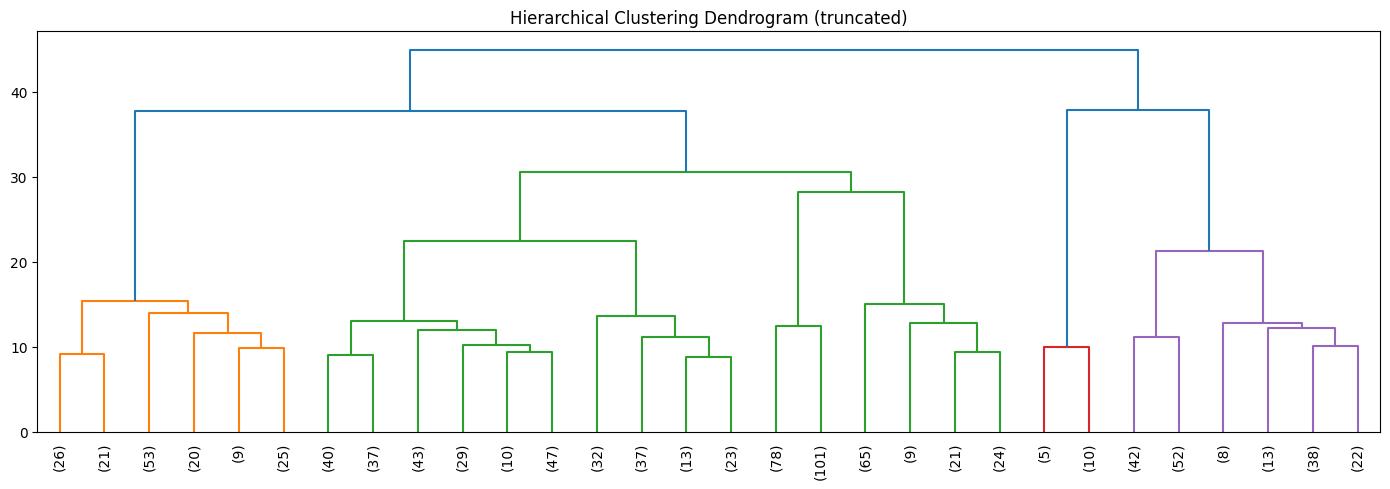

In [4]:
Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(14, 5))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90)
plt.title('Hierarchical Clustering Dendrogram (truncated)')
plt.tight_layout()
plt.show()

hc = AgglomerativeClustering(n_clusters=7, linkage='ward')
hc_labels = hc.fit_predict(X_scaled)

## K-Means Clustering

Elbow method (`KMeans().inertia_` across a range of k, equivalent to R's `fviz_nbclust(..., method="wss")`) to justify k = 7, matching the hierarchical clustering result.

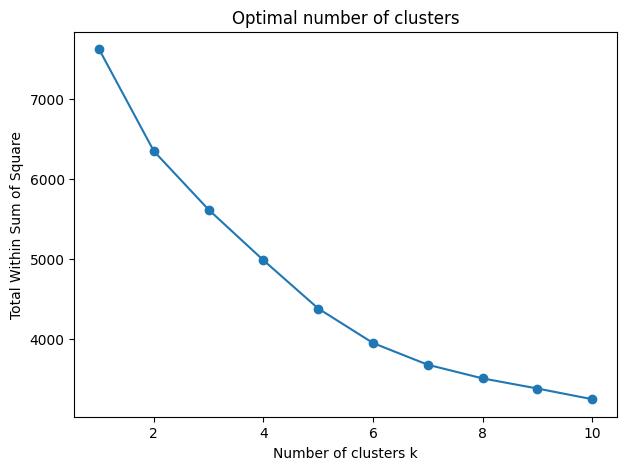

In [5]:
inertias = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(range(1, 11), inertias, marker='o')
plt.xlabel('Number of clusters k')
plt.ylabel('Total Within Sum of Square')
plt.title('Optimal number of clusters')
plt.show()

In [6]:
kmeans = KMeans(n_clusters=7, n_init=10, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
data['cluster'] = clusters

## PCA Visualization

Reduce the feature space to its first two principal components to visualize how well-separated the 7 clusters are.

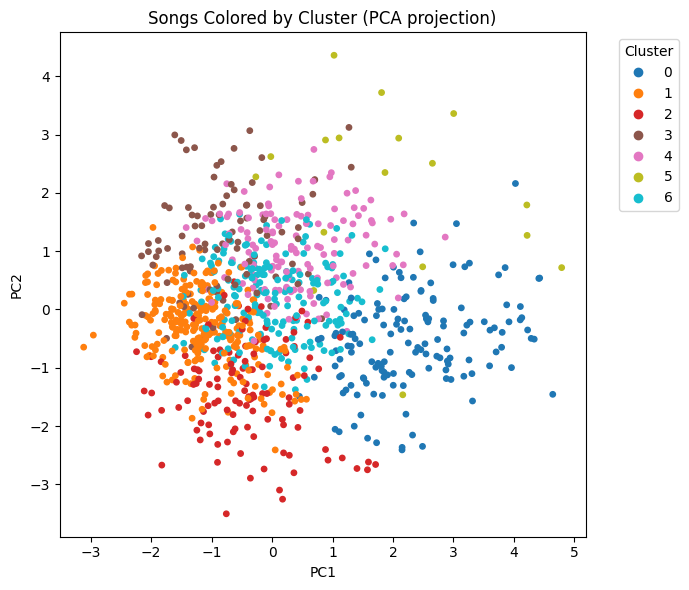

In [7]:
pca = PCA(n_components=2)
pcs = pca.fit_transform(X_scaled)

plt.figure(figsize=(7, 6))
scatter = plt.scatter(pcs[:, 0], pcs[:, 1], c=clusters, cmap='tab10', s=15)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Songs Colored by Cluster (PCA projection)')
plt.legend(*scatter.legend_elements(), title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Song Lookup Helper

Same case-insensitive matching helper as Model 1.

In [8]:
def check_song(song_name, titles):
    song_name_lower = song_name.lower().strip()
    titles_lower = titles.str.lower().str.strip()

    matches = titles_lower[titles_lower == song_name_lower]
    if len(matches) > 0:
        return matches.index[0]

    close = difflib.get_close_matches(song_name_lower, titles_lower.tolist(), n=5, cutoff=0.6)
    if close:
        print("Did you mean one of these songs?")
        for c in close:
            print(" -", c)
    else:
        print("Song not found in the dataset.")
    return None

## Recommender Function

Finds the query song's cluster, then randomly samples 5 other songs from the same cluster — introducing variety while staying within a similar musical "vibe."

In [9]:
def recommender2(song_name):
    idx = check_song(song_name, data['track_name'])
    if idx is None:
        return None

    which_cluster = data['cluster'].loc[idx]
    candidates = data.index[(data['cluster'] == which_cluster) & (data.index != idx)].tolist()

    sample_size = min(5, len(candidates))
    sampled_idx = np.random.choice(candidates, size=sample_size, replace=False)

    return data['track_name'].loc[sampled_idx].tolist()

## Example Usage

In [10]:
recommender2("cruel summer")

['Chemical',
 'Bejeweled',
 'Wild Flower (with youjeen)',
 'Born Singer',
 'I AM WOMAN']